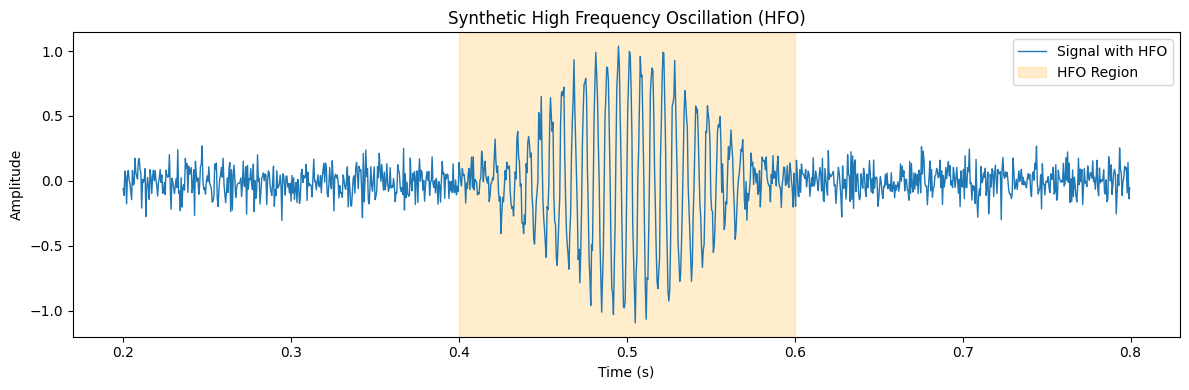

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
fs = 2000  # Sampling rate (Hz)
duration = 1.0  # Total duration in seconds
t = np.arange(0, duration, 1/fs)

# Generate background noise
np.random.seed(0)
noise = 0.1 * np.random.randn(len(t))

# Define HFO parameters
hfo_start = 0.4  # seconds
hfo_end = 0.6    # seconds
hfo_freq = 150   # HFO frequency in Hz
hfo_amp = 1.0    # Amplitude of HFO

# Generate HFO burst (windowed sinusoid)
hfo_signal = np.zeros_like(t)
hfo_window = (t >= hfo_start) & (t <= hfo_end)
hfo_signal[hfo_window] = hfo_amp * np.sin(2 * np.pi * hfo_freq * t[hfo_window])

# Optional: Add envelope (e.g., Gaussian or Hanning window)
envelope = np.hanning(np.sum(hfo_window))
hfo_signal[hfo_window] *= envelope

# Combine signal
signal = noise + hfo_signal

# Plot
valid_range=[int(0.2*len(signal)),int(0.8*len(signal))]
plt.figure(figsize=(12, 4))
plt.plot(t[valid_range[0]:valid_range[1]], signal[valid_range[0]:valid_range[1]], label="Signal with HFO", linewidth=1)
plt.axvspan(hfo_start, hfo_end, color='orange', alpha=0.2, label="HFO Region")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Synthetic High Frequency Oscillation (HFO)")
plt.legend()
plt.tight_layout()
plt.show()


In [2]:
import sys
import os
curr_dir=os.getcwd()
pardir=os.pardir
sys.path.append(os.path.join(curr_dir, pardir))
sys.path.append(os.path.join(curr_dir, pardir, pardir))
# print(f"Current directory: {curr_dir}")
# print(f"Parent directory: {pardir}")
from liset_paper import liset_paper as liset_tk
import numpy as np
import matplotlib.pyplot as plt

from signal_aid import bandpass_filter
import matplotlib.pyplot as plt
# import seaborn as sns

In [3]:

parent=r"E:\neurospark_mat\Download_from_paper"
datasets=os.listdir(parent)
# print("Available datasets:")
# for i, dataset in enumerate(datasets):
#     print(f"{i}: {dataset}")
# print()
# dataset=int(input("Dataset to process: "))
dataset=2
dataset_path=os.path.join(parent,datasets[dataset])
print(f"Processing dataset: {datasets[dataset]}")



Processing dataset: Som2_2019-07-24_12-01-49


In [4]:
liset=liset=liset_tk(dataset_path, shank=1, downsample=False, start=0, verbose=False)

ripples=liset.ripples_GT


In [5]:
channel=1
print(ripples[:10])
window=[5.3,5.5]
mask = (ripples[:, 1] >= window[0]*liset.fs) & (ripples[:, 0] <= window[1]*liset.fs)
window_ripples = ripples[mask]
print(f"Ripples in window {window}: {len(window_ripples)}")
channel_data = liset.data[:, channel]

[[ 60626  62123]
 [161136 162925]
 [174086 175225]
 [255431 256570]
 [310810 312437]
 [316277 317773]
 [326656 327828]
 [443630 444932]
 [446168 447014]
 [513587 514596]]
Ripples in window [5.3, 5.5]: 1


In [6]:
from extract_Nripples.utils_encoding import *
filtered_channel = bandpass_filter(channel_data, fs=liset.fs, bandpass=(100,250), order=4)
# threshold=calculate_threshold(filtered_channel[:120*liset.fs],liset.fs,0.1,0.25,1,plot=False,verbose=False)
# print(f"Threshold: {threshold}")
# up_down=up_down_channel(filtered_channel,threshold,liset.fs,refractory=0,initial_value=None,return_value=False)
# spikes_downsample,spikes_lost=extract_spikes_downsample(up_down,30,)
# print(spikes_downsample.shape)

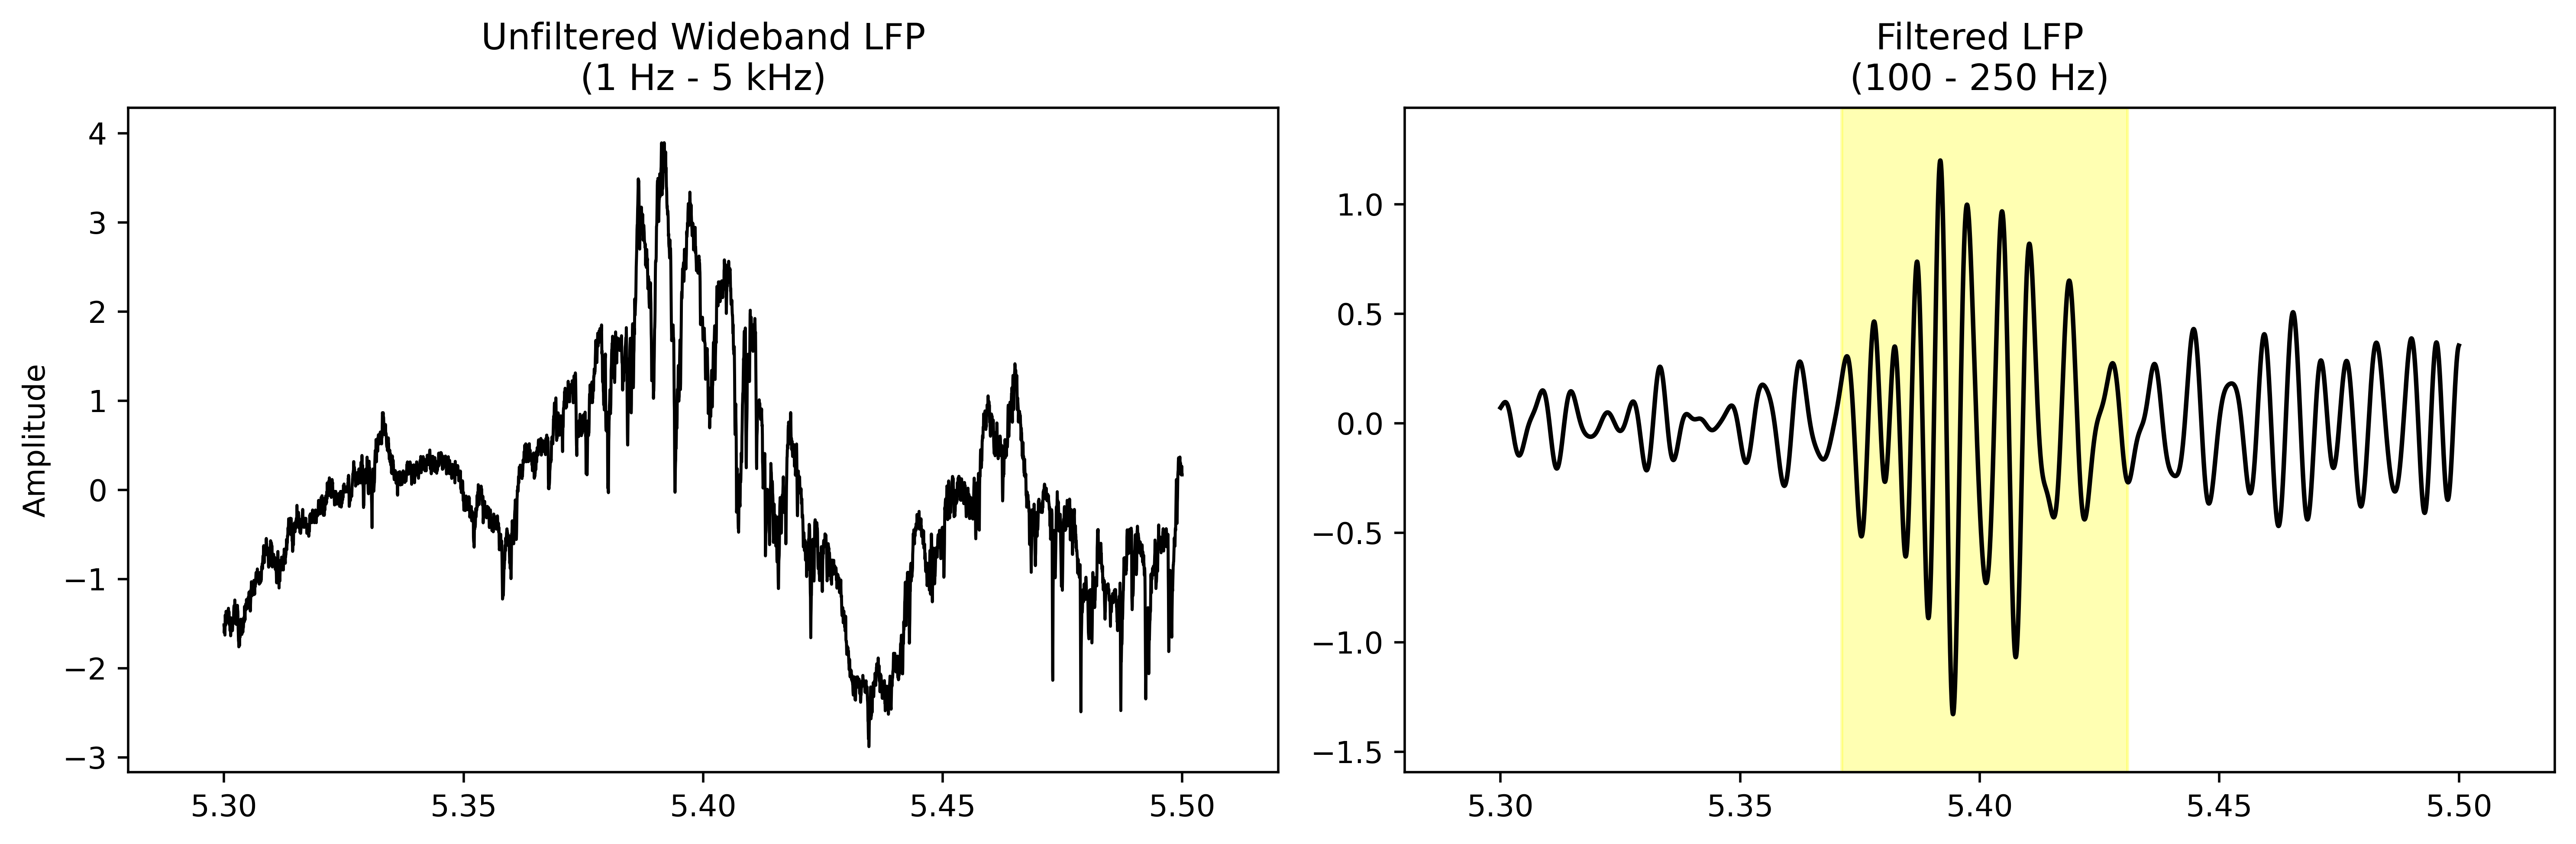

In [51]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4), dpi=500, sharex=True)
window=[5.3,5.5]

start_index = int(window[0] * liset.fs)
end_index = int(window[1] * liset.fs)
time = np.arange(start_index, end_index) / liset.fs

# ----- First plot: Unfiltered Wideband LFP -----
data = channel_data[start_index:end_index]
min_data, max_data = np.min(data), np.max(data)
y_min, y_max = min_data * 1.1, max_data * 1.1

ax[0].plot(time, data, color='black', linewidth=1)
# for i, ripple in enumerate(window_ripples):
#     start, end = ripple / liset.fs
#     ax[0].fill_between([start, end], y_min, y_max, color="yellow", alpha=0.3,
#                        label="GT Ripple" if i == 0 else None)

ax[0].set_xlim(window[0]-0.02, window[1]+0.02)
ax[0].set_ylim(y_min, y_max)
# ax[0].set_xlabel("Time (s)")
ax[0].set_ylabel("Amplitude")
ax[0].set_title("Unfiltered Wideband LFP\n(1 Hz - 5 kHz)")
# ax[0].legend()
# ax[0].grid(axis="x",visible=True, linewidth=0.7,linestyle=":",alpha=0.7)  # <-- Add grid

# ----- Second plot: Filtered Ripple Band -----
filtered_data = filtered_channel[start_index:end_index]
time = np.arange(start_index, end_index) / liset.fs
min_data, max_data = np.min(filtered_data), np.max(filtered_data)
y_min= min_data * 1.2
y_max= max_data * 1.2
ax[1].plot(time, filtered_data, color='black', linewidth=1.5)
for i, ripple in enumerate(window_ripples):
    start, end = ripple / liset.fs
    ax[1].fill_between([start, end], y_min, y_max, color="yellow", alpha=0.3,
                       label="GT Ripple" if i == 0 else None)
ax[1].set_ylim(y_min, y_max)
# ax[1].set_xlabel("Time (s)")
# ax[1].set_ylabel("Amplitude")
ax[1].set_title("Filtered LFP\n(100 - 250 Hz)")
# ax[1].legend()
# ----- Layout and Save -----
plt.tight_layout()
# fig.savefig(os.path.join(curr_dir, "pngs", "ripple_composite.png"), dpi=300)
plt.show()
fig.savefig(os.path.join(curr_dir, "pngs", "filtered_unfiltered.png"), dpi=500)


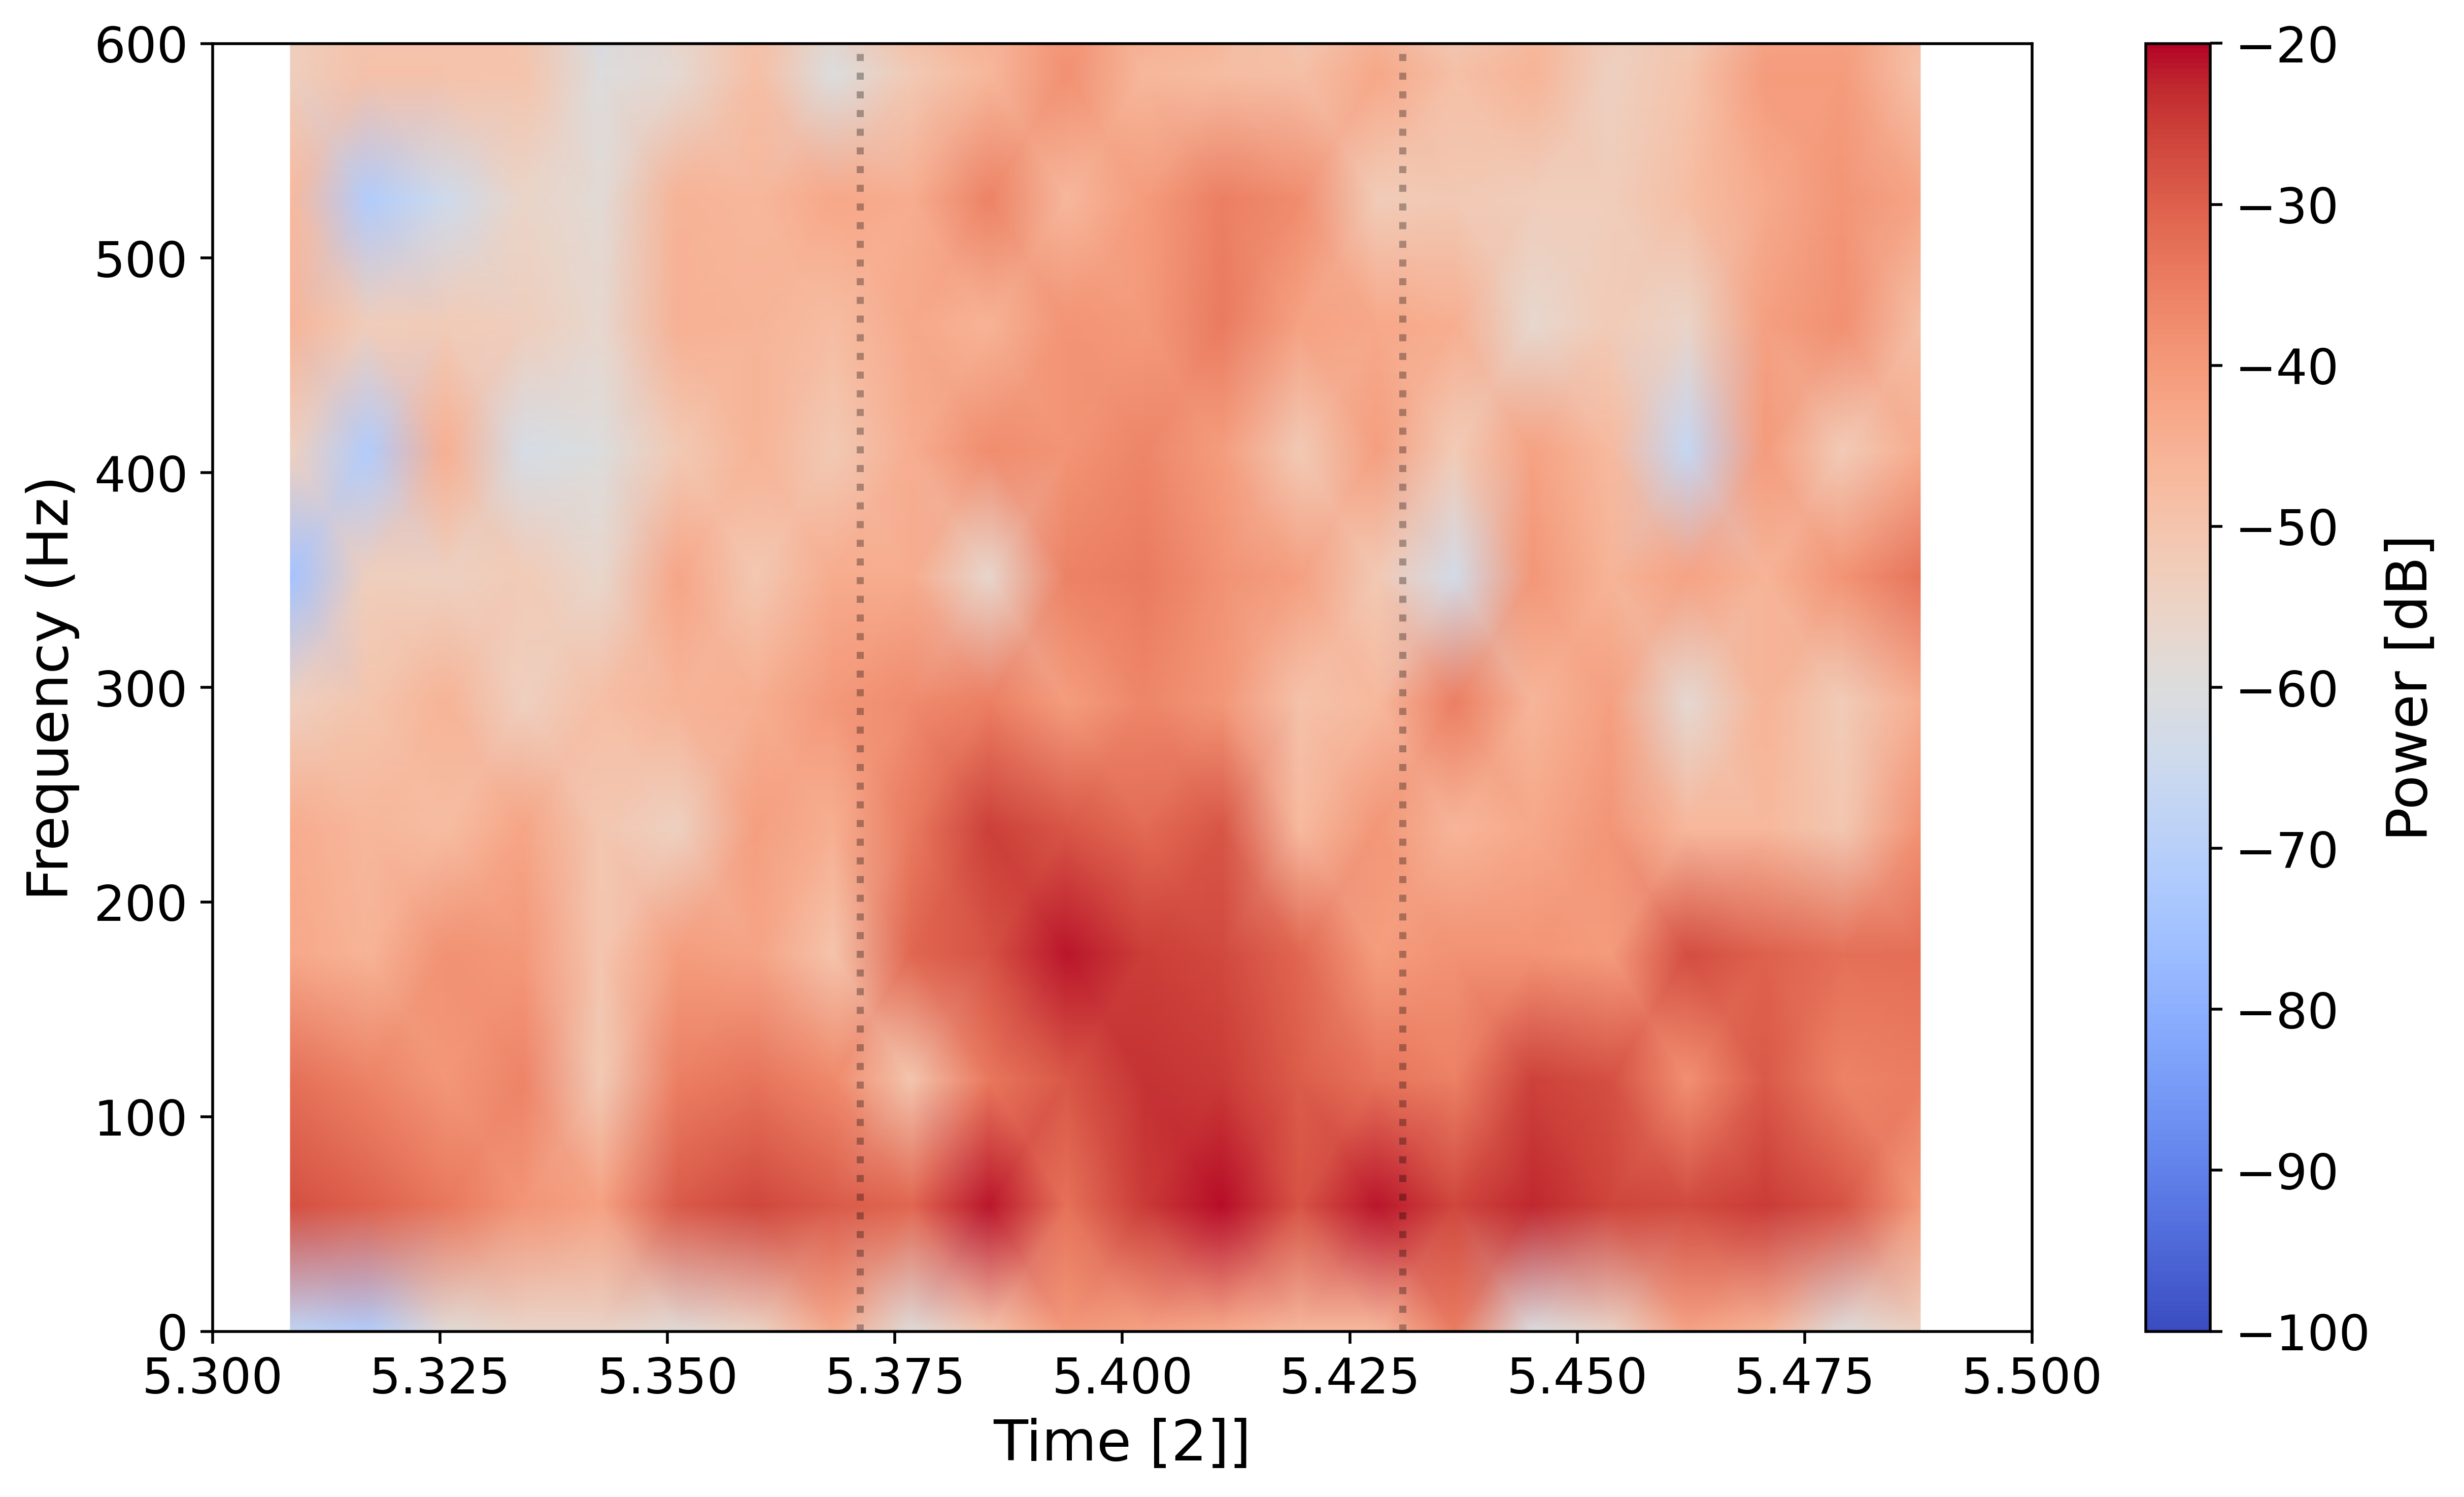

In [49]:
# ----- Separate Figure: Time-Frequency Plot (Spectrogram) -----
from scipy.signal import spectrogram
from matplotlib.colors import Normalize

fig2, ax2 = plt.subplots(figsize=(10, 6), dpi=500)
colormap="coolwarm"
# Spectrogram from unfiltered data
f, t_spec, Sxx = spectrogram(data, fs=liset.fs, nperseg=512, noverlap=256)
# pcm = ax2.pcolormesh(t_spec + window[0], f, 10 * np.log10(Sxx), shading='gouraud', cmap=colormap)


# Convert to dB
Sxx_dB = 10 * np.log10(Sxx + 1e-12)  # Add small constant to avoid log(0)

# Normalize between e.g. -100 dB and -20 dB
vmin, vmax = -100, -20
norm = Normalize(vmin=vmin, vmax=vmax)

# Use in plot
pcm = ax2.pcolormesh(t_spec + window[0], f, Sxx_dB, shading='gouraud', cmap=colormap, norm=norm)

# Focus on relevant ripple-band range
ax2.set_ylim(0, 600)  # Optional: adjust if you want full band
ax2.set_xlim(window[0], window[1])
ax2.set_xlabel("Time [2]]",fontsize=16)
ax2.set_ylabel("Frequency (Hz)",fontsize=16)
# ax2.set_title("Time-Frequency Representation\n(Spectrogram of Unfiltered LFP)")
ax2.tick_params(axis='both', which='major', labelsize=14)  # tick label font size

# # Ground truth ripple overlay
for ripple in window_ripples:
    start, end = ripple / liset.fs
    ax2.vlines([start, end], ymin=0, ymax=600, color='black', alpha=0.3, linewidth=2,linestyle=":")
    # ax2.axvspan(start, end, color="yellow", alpha=0.3)

# Optional: Add colorbar
cbar = plt.colorbar(pcm, ax=ax2,)
cbar.ax.tick_params(labelsize=14)                # ← colorbar tick font size
cbar.set_label('Power [dB]', fontsize=16)        # ← colorbar label font
plt.tight_layout()
fig2.savefig(os.path.join(curr_dir, "pngs", "ripple_spectrogram.png"), dpi=500)
# fig2.savefig("ripple_spectrogram.png", dpi=500)
plt.show()


In [30]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import BoundaryNorm
from matplotlib import cm
from matplotlib import cm
from matplotlib.colors import ListedColormap

base = cm.viridis
colors = base(np.linspace(0, 1, 10))  # 10 colors
cmap = ListedColormap(colors)

# Define boundaries for 10 levels between min and max of Sxx
num_colors = 10
power_dB = 10 * np.log10(Sxx)
vmin, vmax = np.min(power_dB), np.max(power_dB)
bounds = np.linspace(vmin, vmax, num_colors + 1)
norm = BoundaryNorm(bounds, ncolors=num_colors)

# Use a discrete version of the colormap
# cmap = cm.get_cmap('viridis', num_colors)

# Plot with pcolormesh
pcm = ax2.pcolormesh(t_spec + window[0], f, power_dB, shading='gouraud', cmap=cmap, norm=norm)
plt.colorbar(pcm, ax=ax2, ticks=bounds, label='Power (dB)')
plt.show()

C:\Users\Pc\AppData\Local\Temp\ipykernel_26216\2509717880.py:24: UserWarning: Adding colorbar to a different Figure <Figure size 3000x2000 with 4 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  plt.colorbar(pcm, ax=ax2, ticks=bounds, label='Power (dB)')


<Figure size 640x480 with 0 Axes>